In [2]:
import numpy as np
from matplotlib import pyplot as plt
import torch

def plt_hs(hs, min_fr=0.1, masks=None, fig=None, ax=None):

    time_points = hs.shape[0]

    # Select neurons with mean firing rate > 0.1
    mean_fr = hs.mean(axis=0)
    # Get the index where mean_fr > min_fr
    mask = mean_fr > min_fr
    neuron_indices = np.where(mask)[0]
    select_hs = hs[:, neuron_indices]
    del hs

    # Normalize the hs along time points (Sure to be correct!)
    # norm_hs = select_hs / np.linalg.norm(select_hs, axis=0, keepdims=True)
    # 0-1 Normalise method 2
    norm_hs = np.zeros_like(select_hs)
    for n in range(select_hs.shape[1]):
        norm_hs[:, n] = (select_hs[:, n]-np.min(select_hs[:, n]))/(np.max(select_hs[:, n])-np.min(select_hs[:, n]))
    del select_hs
    
    # Sort neurons from maximum firing time
    max_time = np.argmax(norm_hs, axis=0)
    sorted_neuron_indices = np.argsort(max_time)
    norm_hs = norm_hs[:, sorted_neuron_indices]
    num_neurons = norm_hs.shape[1]
    
    # Plot the normalized hs
    ax.imshow(norm_hs.T, aspect='auto', cmap='jet',  
              extent=[0, time_points/10, 0, num_neurons]
              )
    # ax.set_xlabel('Time (s)')
    ax.set_ylabel('Neurons')
    ax.set_xticks(np.linspace(0, norm_hs.shape[0]/10, 6))

    if masks is not None:
        for m in masks:
            ax.axvline(x=m[0], color='white', linestyle='--', linewidth=1)
            ax.axvline(x=m[1], color='white', linestyle='-', linewidth=1)
            # Plot a semi-transparent rectangle to cover the masked region
            ax.add_patch(plt.Rectangle((m[0], 0), m[1]-m[0], norm_hs.shape[1], 
                                       color='white', alpha=0.3))
    
    # Plot the colorbar
    cbar = fig.colorbar(ax.images[0], ax=ax)
    cbar.set_label('Normalized firing rate')
    return norm_hs, fig, ax, sorted_neuron_indices

(7, 200, 512)


Text(0.5, 0, 'Time (s)')

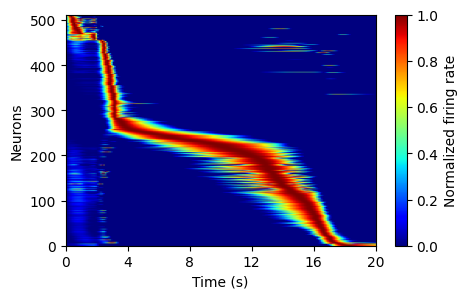

In [4]:
### Load the experimental data ###
load_data_type = '2TS_1_data'
num_neuron = 512
data = np.load(f'../time_exp/{load_data_type}.npy', allow_pickle=True).item()

hidden_states = data['test_hidden_states']
print(hidden_states.shape)

fr = hidden_states[0]

# Plot the hidden states
fig, ax = plt.subplots(figsize=(5, 3))
norm_hs, fig, ax, neuron_idx = plt_hs(fr, ax=ax, fig=fig, min_fr=0.)
ax.set_xlabel('Time (s)')

In [3]:
# Load model weights 
model_dict = torch.load(f'../time_exp/2TS_1_rnn.pth', map_location=torch.device('cuda'))

# Get the weights and biases
trained_Wrc = model_dict['recurrent_layers.0.leaky_layer.linear_layer.weight'].cpu().numpy()

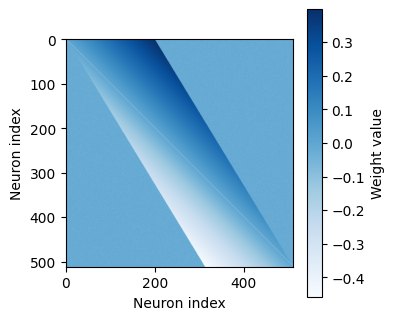

In [34]:
# Create a recurrent weight matrix
Wrc = np.zeros((num_neuron, num_neuron))
# Assign negative weights to all elements of Wrc
Wrc = np.random.normal(loc=-0.02, scale=0.01, size=(num_neuron, num_neuron))
# Initiate the diagonal +1 elements
diags = np.random.normal(loc=-0.15, scale=0.02, size=(num_neuron)) #np.linspace(-0.15, 0, num_neuron)
Delta, gain,gain2 = 200, 0.002,0.0023
# Set up limits for each row
limits1 = np.linspace(Delta, 0, num_neuron, dtype=int)
limits2 = np.linspace(0, Delta, num_neuron, dtype=int)
for i in range(num_neuron):
    Wrc[i,i] = diags[i]
    for j in range(num_neuron):
        if j > i and j < (i + limits1[i]):
            Wrc[i,j] = (j-i) * gain
        if j < i and j > (i - limits2[i]):
            Wrc[i,j] = (j-i) * gain2
    # for k in range(10):
    #     Wrc[i,(i+k+1)%num_neuron] += (k+1) * 0.3
    
    
# Plot the Wrc matrix
plt.figure(figsize=(4,3.5))
plt.imshow(Wrc, cmap='Blues')
plt.colorbar(label='Weight value')
# plt.title('Recurrent Weight Matrix Wrc')
plt.xlabel('Neuron index')
plt.ylabel('Neuron index')
plt.tight_layout()
plt.savefig('Wrc_theory.png', transparent=True, dpi=500)

np.save('Wrc_theory.npy', Wrc)

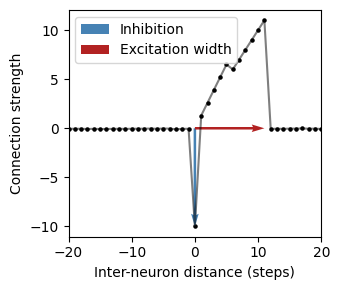

In [140]:
# Plot the first row of Wrc

row_idx = 0
N = Wrc.shape[0]
row = Wrc[row_idx]

# roll so the minimum lands at the center index
imin = row_idx
center = N // 2                      # choose left-of-center for even N
rolled = np.roll(row, center - imin)

# x coordinates aligned to integer steps and containing 0 exactly
x = np.arange(N) - center            # works for even/odd N

plt.figure(figsize=(3.5,3))
plt.scatter(x, rolled, s=5, color='black')
plt.plot(x, rolled, color='black', alpha=0.5)
plt.xlabel('Inter-neuron distance (steps)')
plt.ylabel('Connection strength')


plt.quiver(0, 0, 0, min(rolled), 
           angles='xy', scale_units='xy', scale=1, color='steelblue', width=0.01, label='Inhibition')
plt.quiver(0, 0, np.argmax(rolled)-center, 0,
           angles='xy', scale_units='xy', scale=1, color='firebrick', width=0.01, label='Excitation width')

plt.xlim(-20, 20)
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('Wrc_connectivity.png', dpi=500, transparent=True)

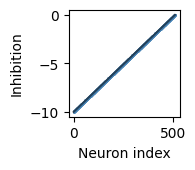

In [143]:
# Plot the diagonal of Wrc
plt.figure(figsize=(2, 1.8))
plt.scatter(np.arange(num_neuron), np.diag(Wrc), s=1, color='steelblue')
plt.plot(np.diag(Wrc), color='black', alpha=0.5)
plt.xlabel('Neuron index')
plt.ylabel('Inhibition')
plt.tight_layout()
plt.savefig('Wrc_inhibition.png', dpi=500, transparent=True)

[np.int64(11), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(10), np.int64(9), np.int64(9), np.int64(9), np.int64(9), np.int64(9), np.int64(9), np.int64(9), np.int64(9), np.int64(9), np.int64(9), np.int64(9), np.int64(9), np.int64(9), np.int64(9), np.int64(9), np.int64(9), np.int64(9), np.int64(9), np.int64(9), np.int64(9), np.int64(9), np.int64(9), np.int64(9), np.int64(9), np.int64(9), np.int64(9), np.int64(9), np.int64(9), np.int64(9), np.int64(9), np.int6

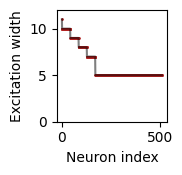

In [146]:
# Plot the excitation width of each neurons 
excitation_widths = []
for i in range(num_neuron):
    row = Wrc[i]
    imin = i
    center = N // 2                      
    rolled = np.roll(row, -imin)
    width = max(5, np.argmax(rolled))
    excitation_widths.append(width)
print(excitation_widths)
plt.figure(figsize=(2, 1.85))
plt.scatter(np.arange(num_neuron), excitation_widths, s=1, color='firebrick')
plt.plot(excitation_widths, color='black', alpha=0.5)
plt.ylim(0, 12)
plt.xlabel('Neuron index')
plt.ylabel('Excitation width')
plt.tight_layout()
plt.savefig('Wrc_excite_width.png', dpi=500, transparent=True)

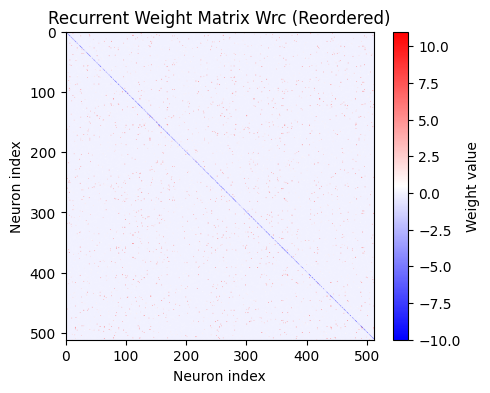

In [309]:
# Reorder the Wrc according to the inverse of the neuron_idx
Wrc_new = Wrc[np.ix_(neuron_idx, neuron_idx)]
plt.figure(figsize=(5,4))
plt.imshow(Wrc_new, cmap='bwr')
plt.colorbar(label='Weight value')
plt.title('Recurrent Weight Matrix Wrc (Reordered)')
plt.xlabel('Neuron index')
plt.ylabel('Neuron index')
plt.show()